In [1]:
import numpy as np
from rubin_scheduler.scheduler.utils import restore_scheduler
from rubin_scheduler.scheduler.model_observatory import ModelObservatory
import matplotlib.pylab as plt
%matplotlib inline
import pandas as pd
from fbs_config import SURVEY_START_MJD, get_scheduler
import sqlite3
import healpy as hp

In [2]:
con = sqlite3.connect("r_start_v5.3.5_0yrs.db")
observations = pd.read_sql("select * from observations;", con)
con.close()

In [3]:
indx = np.where(observations["night"] == 6)[0]

observations.iloc[indx]

,observationId,fieldRA,fieldDec,observationStartMJD,flush_by_mjd,visitExposureTime,band,filter,rotSkyPos,rotSkyPos_desired,...,moonRA,moonDec,moonDistance,solarElong,moonPhase,cummTelAz,observation_reason,science_program,cloud_extinction,extinction_limit
2323,2323,207.504315,7.924212,61212.949658,0.0,30.0,r,r_57,90.993301,0.0,...,179.570235,-2.083406,29.603979,111.209108,50.130287,37.817578,singles_r,BLOCK-419,0.0,100.0
2324,2324,208.013601,2.939909,61212.950093,0.0,30.0,r,r_57,94.158309,0.0,...,179.572976,-2.086050,28.871484,114.009192,50.132037,42.438248,singles_r,BLOCK-419,0.0,100.0
2325,2325,203.909326,-23.423034,61212.950718,0.0,30.0,r,r_57,124.910013,0.0,...,179.576917,-2.089851,31.785580,119.760020,50.134554,76.925216,singles_r,BLOCK-419,0.0,100.0
2326,2326,204.946398,-31.892946,61212.951268,0.0,30.0,r,r_57,147.309588,0.0,...,179.580385,-2.093194,38.189869,122.410110,50.136768,101.423711,singles_r,BLOCK-419,0.0,100.0
2327,2327,206.319548,-34.700811,61212.951722,0.0,30.0,r,r_57,154.116534,0.0,...,179.583250,-2.095955,41.012350,123.935814,50.138597,109.384547,singles_r,BLOCK-419,0.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3258,3258,340.184459,-33.672587,61213.443982,0.0,30.0,y,y_10,322.239346,0.0,...,185.088648,-4.911710,134.796446,119.242318,53.300172,107.946436,singles_y,BLOCK-419,0.0,100.0
3259,3259,327.856325,-32.877793,61213.444449,0.0,30.0,y,y_10,331.823060,0.0,...,185.096186,-4.914387,128.289439,129.358272,53.304346,110.780760,singles_y,BLOCK-419,0.0,100.0
3260,3260,324.418814,-34.322904,61213.444876,0.0,30.0,y,y_10,330.928482,0.0,...,185.103072,-4.916833,125.144332,132.298516,53.308158,107.502035,singles_y,BLOCK-419,0.0,100.0
3261,3261,342.021312,-28.270519,61213.445399,0.0,30.0,y,y_10,340.175398,0.0,...,185.111499,-4.919826,140.046046,116.590152,53.312825,127.302631,singles_y,BLOCK-419,0.0,100.0


In [4]:
nside, scheduler = get_scheduler(for_simulation=True)
observatory = ModelObservatory(mjd_start=SURVEY_START_MJD)

/Users/yoachim/git_repos/sims_featureScheduler_runs5.3/technical/r_start/lsst_surveys.py:82: RuntimeWarning: invalid value encountered in power
  min_fwhm = zenith_fwhm_limit * (np.power(min_airmass, 0.6))


In [5]:
scheduler, observatory = restore_scheduler(2323-1, scheduler, observatory, "r_start_v5.3.5_0yrs.db", band_sched=None, fast=True)

/Users/yoachim/git_repos/rubin_scheduler/rubin_scheduler/scheduler/utils/utils.py:618: UserWarning: Column note not found.
  warnings.warn(f"Column {key} not found.")


In [6]:
observatory.mjd += 0.2
bool, new_mjd = observatory.check_mjd(observatory.mjd)
observatory.mjd = new_mjd

In [7]:
conditions = observatory.return_conditions()

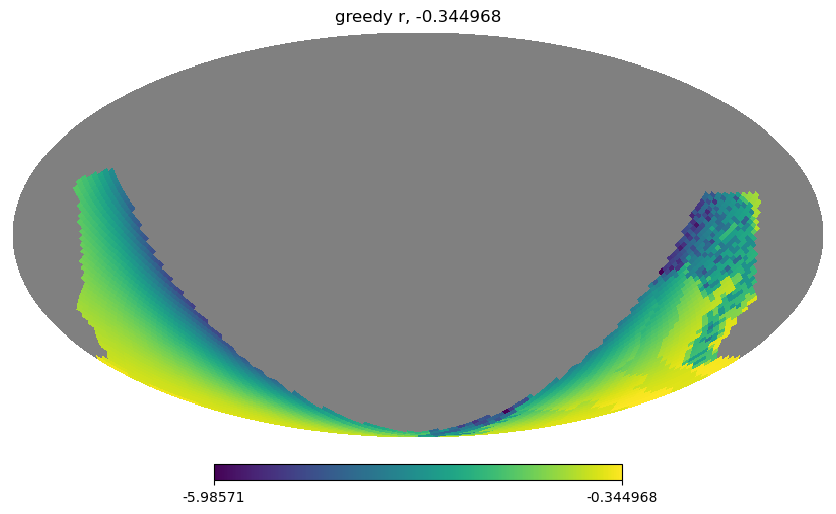

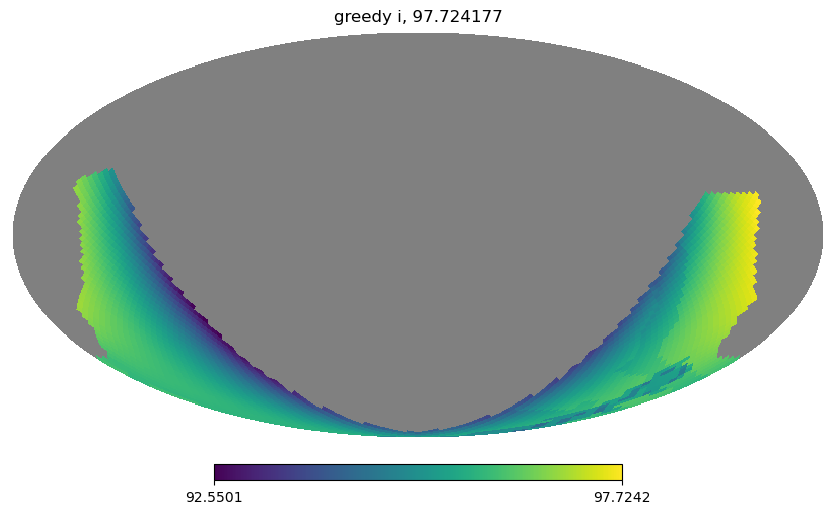

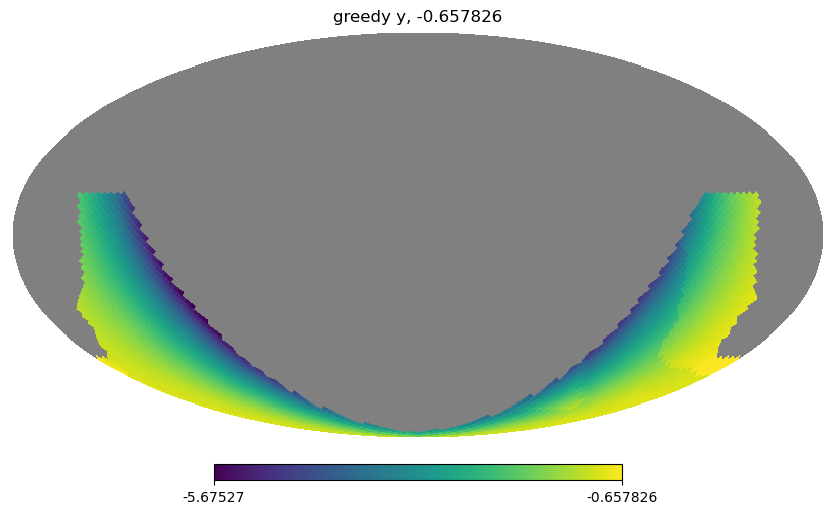

In [8]:
for i in range(6):
    reward = scheduler.survey_lists[-1][i].calc_reward_function(conditions)
    if np.size(reward) > 1:
        hp.mollview(reward, title=scheduler.survey_lists[-1][i].survey_name + ", %f" % np.nanmax(reward))

In [9]:
scheduler.update_conditions(conditions)
ack = scheduler.request_observation()

In [10]:
ack

ObservationArray([(0, 3.62163352, 0.1383036, 0., 0., 30., 'i', 'i_39', 1.5881327, 0., 1, 0., 0., 0., 0., 0., 0, 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 'greedy i', 'lowdust', 2425, 0., 0.54692971, 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 'singles_i', 'BLOCK-419', 0., 100., 'greedy i')],
                 dtype=[('ID', '<i8'), ('RA', '<f8'), ('dec', '<f8'), ('mjd', '<f8'), ('flush_by_mjd', '<f8'), ('exptime', '<f8'), ('band', '<U10'), ('filter', '<U10'), ('rotSkyPos', '<f8'), ('rotSkyPos_desired', '<f8'), ('nexp', '<i8'), ('airmass', '<f8'), ('FWHM_500', '<f8'), ('FWHMeff', '<f8'), ('FWHM_geometric', '<f8'), ('skybrightness', '<f8'), ('night', '<i8'), ('slewtime', '<f8'), ('visittime', '<f8'), ('slewdist', '<f8'), ('fivesigmadepth', '<f8'), ('alt', '<f8'), ('az', '<f8'), ('pa', '<f8'), ('pseudo_pa', '<f8'), ('clouds', '<f8'), ('moonAlt', '<f8'), ('sunAlt', '<f8'), ('scheduler_note', '<U60'), ('target_name', '<U60'), ('target_id', '<i8'), ('lmst', '<f8'), ('rotTelPos', '<f8'), ('ro

In [76]:
conditions.mjd

np.float64(61212.94936451176)

np.float64(61206.5)

In [12]:
scheduler.survey_lists[-1][2].basis_functions